### 供應鏈風險分數 多年度綜合統計

讀取 `2-1_llm_ready(extract risk paragraph) .ipynb` 產出的 article-level / snippet-level CSV，針對固定的年份清單逐年計算分數分布、零分比例、每篇 snippet 平均數量、matched_bigram 頻率、`llm_input_text` 重複率（通稿轉載/樣板文字偵測）等統計，在 cell output 用 pandas 表格與圖表呈現，最後輸出成一個 Excel 檔（每個年份各一個工作表 + 一個跨年度比較的 Summary 工作表，內含趨勢圖）。

- 輸入來源：`output/llm_ready_整年/{year}/`
- 輸出檔案：`output/multi_year_summary_stats.xlsx`
- 找不到檔案的年份會自動印警告並跳過，不會中斷；之後其他年份的檔案到位，重新執行整個 notebook 就會自動抓進來

In [1]:
import os
import gc
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display

# 讓 matplotlib 圖表的中文標籤正常顯示
_font_candidates = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'KaiTi', 'DengXian', 'DejaVu Sans']
_available_fonts = {f.name for f in mpl.font_manager.fontManager.ttflist}
for _font in _font_candidates:
    if _font in _available_fonts:
        plt.rcParams['font.sans-serif'] = [_font]
        break
else:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 年份清單：找不到檔案的年份會自動跳過，之後檔案到位重跑即可
YEARS = [2000, 2006, 2012, 2018, 2024]

input_base_dir = r'C:\Users\user\Desktop\ravenpack\RP_SCrisk\2_calculate_supply_chain_risk_and_extract_segments\output\llm_ready_整年'
output_dir = r'C:\Users\user\Desktop\ravenpack\RP_SCrisk\2_calculate_supply_chain_risk_and_extract_segments\output'
excel_path = os.path.join(output_dir, 'multi_year_summary_stats_v3.xlsx')


def resolve_year_paths(year, base_dir):
    """回傳 (article_csv 路徑, snippet_csv 路徑)"""
    year_dir = os.path.join(base_dir, str(year))
    article_path = os.path.join(year_dir, f'article_level_scores_{year}.csv')
    snippet_path = os.path.join(year_dir, f'llm_ready_data_{year}_context50_snippetlevel.csv')


    return article_path, snippet_path

In [2]:
def compute_year_stats(year, base_dir):
    """讀取單一年份的 article-level / snippet-level 檔案，算出分數分布、零分比例、
    每篇 snippet 平均數量、matched_bigram 頻率、llm_input_text 重複率等統計。
    檔案不存在就印警告並回傳 None。"""
    article_path, snippet_path = resolve_year_paths(year, base_dir)

    if not (os.path.exists(article_path) and os.path.exists(snippet_path)):
        print(f"[跳過] {year} 年：找不到輸出檔案")
        print(f"        預期路徑: {article_path}")
        print(f"                  {snippet_path}")
        return None

    print(f"[處理中] {year} 年 ...")
    df_article_y = pd.read_csv(article_path)
    df_snippet_y = pd.read_csv(snippet_path)

    # 1. 分數分布 + 零分比例
    bins = [-0.0001, 0, 0.01, 0.05, 0.1, 0.2, 0.5, float('inf')]
    labels = ['0', '(0, 0.01]', '(0.01, 0.05]', '(0.05, 0.1]', '(0.1, 0.2]', '(0.2, 0.5]', '(0.5, +]']
    score_bucket = pd.cut(df_article_y['sc_risk_score'], bins=bins, labels=labels)
    bucket_dist = score_bucket.value_counts().sort_index()
    bucket_table = pd.DataFrame({
        '文章數': bucket_dist,
        '佔比(%)': (bucket_dist / len(df_article_y) * 100).round(2)
    }).reset_index().rename(columns={'index': 'sc_risk_score 區間', 'sc_risk_score': 'sc_risk_score 區間'})

    total_articles = len(df_article_y)
    zero_count = int((df_article_y['sc_risk_score'] == 0).sum())
    zero_ratio = zero_count / total_articles if total_articles else float('nan')
    score_describe = df_article_y['sc_risk_score'].describe()

    # 2. 每篇 snippet 平均數量
    snippet_counts = df_snippet_y.groupby('file_name').size()
    avg_snippets_per_snippet_article = snippet_counts.mean() if len(snippet_counts) else float('nan')
    avg_snippets_per_all_article = snippet_counts.sum() / total_articles if total_articles else float('nan')

    # 3. matched_bigram 頻率
    bigram_freq = df_snippet_y['matched_bigram'].value_counts()
    bigram_top20 = bigram_freq.head(20).reset_index()
    bigram_top20.columns = ['matched_bigram', '出現次數']

    # 4. 其他輔助欄位
    event_type_top10 = df_article_y['event_type'].value_counts().head(10).reset_index()
    event_type_top10.columns = ['event_type', '文章數']
    total_bigrams_describe = df_article_y['total_bigrams'].describe()

    # 5. llm_input_text 重複偵測（通稿轉載/免責聲明等樣板文字）
    #    一次 groupby 同時算出現次數與涉及的不同文章數，避免對長文字欄位重複掃描
    text_stats = df_snippet_y.groupby('llm_input_text').agg(
        出現次數=('file_name', 'size'),
        不同文章數=('file_name', 'nunique'),
    ).sort_values('出現次數', ascending=False)

    dup_mask = text_stats['出現次數'] > 1
    dup_rows = int(text_stats.loc[dup_mask, '出現次數'].sum())
    unique_texts = int(len(text_stats))
    total_snippets = len(df_snippet_y)
    dup_ratio = dup_rows / total_snippets if total_snippets else float('nan')

    # 6. 重複文字前300名，方便人工檢視
    dup_top300 = text_stats[dup_mask].head(300).reset_index()

    result = {
        'year': year,
        'total_articles': total_articles,
        'zero_count': zero_count,
        'zero_ratio': zero_ratio,
        'mean_score': score_describe['mean'],
        'median_score': score_describe['50%'],
        'max_score': score_describe['max'],
        'total_snippets': total_snippets,
        'articles_with_snippets': len(snippet_counts),
        'avg_snippets_per_snippet_article': avg_snippets_per_snippet_article,
        'avg_snippets_per_all_article': avg_snippets_per_all_article,
        'unique_matched_bigrams': int(bigram_freq.shape[0]),
        'top_matched_bigram': bigram_freq.index[0] if len(bigram_freq) else None,
        'top_matched_bigram_count': int(bigram_freq.iloc[0]) if len(bigram_freq) else 0,
        'dup_rows': dup_rows,
        'unique_texts': unique_texts,
        'dup_ratio': dup_ratio,
        # 完整小表格，output 預覽 + Excel 分頁用
        'score_describe': score_describe,
        'bucket_table': bucket_table,
        'bigram_top20': bigram_top20,
        'event_type_top10': event_type_top10,
        'total_bigrams_describe': total_bigrams_describe,
        'dup_top300': dup_top300,
        # 畫圖用，只留必要欄位即可釋放記憶體
        'score_sample': df_article_y['sc_risk_score'].copy(),
    }

    # 算完一年就把大表釋放掉
    del df_article_y, df_snippet_y
    gc.collect()
    return result

In [3]:
yearly_stats = {}
for y in YEARS:
    r = compute_year_stats(y, input_base_dir)
    if r is not None:
        yearly_stats[y] = r

processed_years = sorted(yearly_stats.keys())
skipped_years = sorted(set(YEARS) - set(yearly_stats.keys()))
print(f"\n共處理 {len(processed_years)}/{len(YEARS)} 個年份: {processed_years}")
if skipped_years:
    print(f"跳過（找不到檔案）: {skipped_years}")

[處理中] 2000 年 ...
[處理中] 2006 年 ...
[處理中] 2012 年 ...
[處理中] 2018 年 ...
[處理中] 2024 年 ...

共處理 5/5 個年份: [2000, 2006, 2012, 2018, 2024]


#### Output 預覽：各年度統計表 + 跨年度比較表

In [4]:
# 每個處理到的年份，秀出分數分桶分布、matched_bigram 前 10 名、llm_input_text 重複狀況
from IPython.display import display
for y in processed_years:
    r = yearly_stats[y]
    print(f"===== {y} 年 =====")
    print(f"文章數: {r['total_articles']:,}　零分比例: {r['zero_ratio']:.2%}　"
          f"平均分數: {r['mean_score']:.4f}")
    
    # 重複比例定義為重複的 llm_input_text 列數除以總snippet列數
    print(f"llm_input_text 重複列數: {r['dup_rows']:,} / 總列數: {r['total_snippets']:,} "
          f"= {r['dup_ratio']:.2%}　不重複片段數: {r['unique_texts']:,}")

# 跨年度比較表
summary_rows = []
for y in processed_years:
    r = yearly_stats[y]
    summary_rows.append({
        '年份': y,
        '文章數': r['total_articles'],
        '零分比例': round(r['zero_ratio'], 4),
        '平均分數': r['mean_score'],
        '中位數分數': r['median_score'],
        '有snippet文章平均snippet數': round(r['avg_snippets_per_snippet_article'], 2),
        '全部文章平均snippet數': round(r['avg_snippets_per_all_article'], 2),
        'snippet總數': r['total_snippets'],
        '最常見matched_bigram': r['top_matched_bigram'],
        'llm_input_text重複比例': round(r['dup_ratio'], 4),
    })
summary_df = pd.DataFrame(summary_rows)

print("===== 跨年度比較 =====")
display(summary_df)

===== 2000 年 =====
文章數: 181,492　零分比例: 50.39%　平均分數: 0.0072
llm_input_text 重複列數: 116,239 / 總列數: 248,628 = 46.75%　不重複片段數: 164,371
===== 2006 年 =====
文章數: 418,916　零分比例: 43.74%　平均分數: 0.0082
llm_input_text 重複列數: 584,203 / 總列數: 806,098 = 72.47%　不重複片段數: 357,040
===== 2012 年 =====
文章數: 474,314　零分比例: 48.93%　平均分數: 0.0079
llm_input_text 重複列數: 611,652 / 總列數: 889,880 = 68.73%　不重複片段數: 422,934
===== 2018 年 =====
文章數: 696,821　零分比例: 50.13%　平均分數: 0.0089
llm_input_text 重複列數: 881,360 / 總列數: 1,222,939 = 72.07%　不重複片段數: 517,863
===== 2024 年 =====
文章數: 1,326,211　零分比例: 56.09%　平均分數: 0.0121
llm_input_text 重複列數: 1,569,696 / 總列數: 2,207,756 = 71.10%　不重複片段數: 939,278
===== 跨年度比較 =====


,年份,文章數,零分比例,平均分數,中位數分數,有snippet文章平均snippet數,全部文章平均snippet數,snippet總數,最常見matched_bigram,llm_input_text重複比例
0,2000,181492,0.5039,0.007237,0.000000,2.76,1.37,248628,and_uncertainties,0.4675
1,2006,418916,0.4374,0.008250,0.001167,3.42,1.92,806098,and_uncertainties,0.7247
2,2012,474314,0.4893,0.007937,0.000323,3.67,1.88,889880,and_uncertainties,0.6873
3,2018,696821,0.5013,0.008896,0.000000,3.52,1.76,1222939,and_uncertainties,0.7207
4,2024,1326211,0.5609,0.012065,0.000000,3.79,1.66,2207756,and_uncertainties,0.7110


#### 圖表：跨年度趨勢 + 各年分數分布

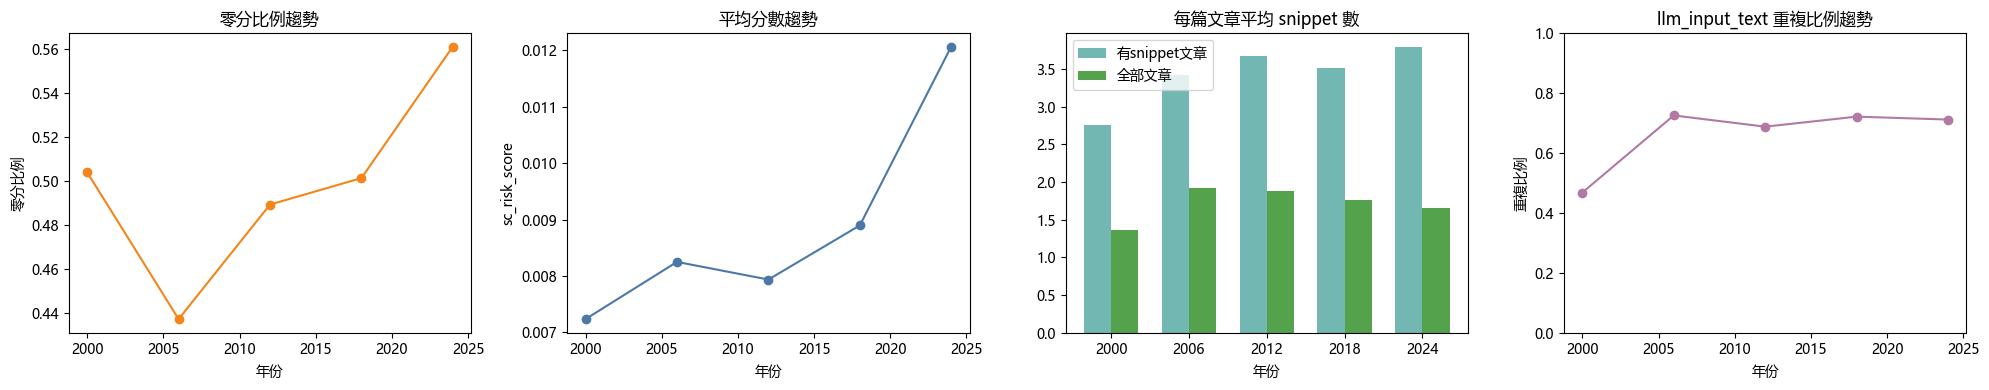

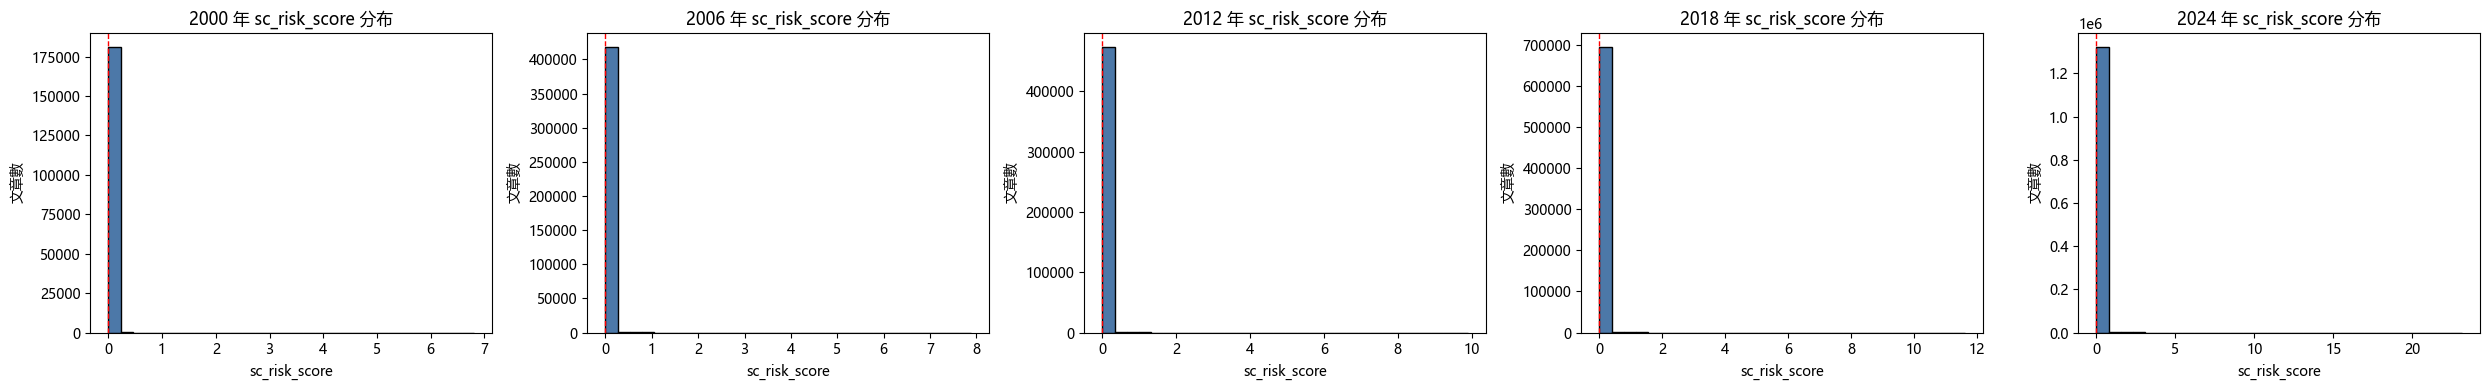

In [5]:
# 1) 跨年度趨勢：零分比例 / 平均分數 / 平均 snippet 數 / llm_input_text 重複比例
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].plot(summary_df['年份'], summary_df['零分比例'], marker='o', color='#F58518')
axes[0].set_title('零分比例趨勢')
axes[0].set_xlabel('年份')
axes[0].set_ylabel('零分比例')

axes[1].plot(summary_df['年份'], summary_df['平均分數'], marker='o', color='#4C78A8')
axes[1].set_title('平均分數趨勢')
axes[1].set_xlabel('年份')
axes[1].set_ylabel('sc_risk_score')

width = 0.35
x = range(len(summary_df))
axes[2].bar([i - width / 2 for i in x], summary_df['有snippet文章平均snippet數'], width, label='有snippet文章', color='#72B7B2')
axes[2].bar([i + width / 2 for i in x], summary_df['全部文章平均snippet數'], width, label='全部文章', color='#54A24B')
axes[2].set_title('每篇文章平均 snippet 數')
axes[2].set_xlabel('年份')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(summary_df['年份'])
axes[2].legend()

axes[3].plot(summary_df['年份'], summary_df['llm_input_text重複比例'], marker='o', color='#B279A2')
axes[3].set_title('llm_input_text 重複比例趨勢')
axes[3].set_xlabel('年份')
axes[3].set_ylabel('重複比例')
axes[3].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 2) 各年 sc_risk_score 分布直方圖
n_years = len(processed_years)
fig, axes = plt.subplots(1, n_years, figsize=(5 * n_years, 4), squeeze=False)
for ax, y in zip(axes[0], processed_years):
    r = yearly_stats[y]
    ax.hist(r['score_sample'], bins=30, color='#4C78A8', edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{y} 年 sc_risk_score 分布')
    ax.set_xlabel('sc_risk_score')
    ax.set_ylabel('文章數')
plt.tight_layout()
plt.show()

#### 輸出 Excel：各年份一個工作表 + Summary 跨年度比較（純 pandas 表格，不含內建圖表/強制字型）

In [7]:
def write_year_sheet(writer, year, r):
    """把單一年份的統計量寫成一個分頁，多個小表格依序往下疊。"""
    sheet_name = str(year)
    writer.book.create_sheet(sheet_name)
    ws = writer.sheets[sheet_name]
    row = 1

    ws.cell(row=row, column=1, value=f"{year} 年 sc_risk_score 描述性統計"); row += 1
    r['score_describe'].to_frame('數值').to_excel(writer, sheet_name=sheet_name, startrow=row, index=True)
    row += len(r['score_describe']) + 2

    ws.cell(row=row, column=1, value=f"{year} 年 sc_risk_score 分桶分布"); row += 1
    r['bucket_table'].to_excel(writer, sheet_name=sheet_name, startrow=row, index=False)
    row += len(r['bucket_table']) + 2

    ws.cell(row=row, column=1, value=(
        f"{year} 年零分比例: {r['zero_ratio']:.2%}"
        f"（{r['zero_count']:,} / {r['total_articles']:,} 篇）"
    ))
    row += 2

    ws.cell(row=row, column=1, value=f"{year} 年每篇 snippet 數量"); row += 1
    ws.cell(row=row, column=1, value=(
        f"有 snippet 的文章平均 snippet 數: {r['avg_snippets_per_snippet_article']:.2f}"
        f"（{r['articles_with_snippets']:,} 篇）"
    )); row += 1
    ws.cell(row=row, column=1, value=(
        f"全部文章平均 snippet 數: {r['avg_snippets_per_all_article']:.2f}"
        f"（{r['total_articles']:,} 篇）"
    )); row += 2

    ws.cell(row=row, column=1, value=f"{year} 年 matched_bigram 出現次數前 20 名"); row += 1
    r['bigram_top20'].to_excel(writer, sheet_name=sheet_name, startrow=row, index=False)
    row += len(r['bigram_top20']) + 2

    ws.cell(row=row, column=1, value=f"{year} 年 event_type 分布前 10 名"); row += 1
    r['event_type_top10'].to_excel(writer, sheet_name=sheet_name, startrow=row, index=False)
    row += len(r['event_type_top10']) + 2

    ws.cell(row=row, column=1, value=f"{year} 年 total_bigrams 描述性統計"); row += 1
    r['total_bigrams_describe'].to_frame('數值').to_excel(writer, sheet_name=sheet_name, startrow=row, index=True)
    row += len(r['total_bigrams_describe']) + 2

    ws.cell(row=row, column=1, value=(
        f"{year} 年 llm_input_text 重複狀況（通稿轉載/樣板文字偵測）"
    )); row += 1
    ws.cell(row=row, column=1, value=(
        f"重複列數: {r['dup_rows']:,} / 總列數: {r['total_snippets']:,} = {r['dup_ratio']:.2%}"
        f"　不重複片段數: {r['unique_texts']:,}"
    )); row += 2
    ws.cell(row=row, column=1, value=f"{year} 年重複次數最多的片段前 300 名"); row += 1
    r['dup_top300'].to_excel(writer, sheet_name=sheet_name, startrow=row, index=False)


if not yearly_stats:
    print("沒有任何年份有資料可以輸出，先確認 output 資料夾底下有沒有對應年份的檔案。")
else:
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        # 逐年分頁
        for y in processed_years:
            write_year_sheet(writer, y, yearly_stats[y])

        # 綜合摘要分頁（沿用前面 cell 算好的 summary_df）
        summary_df.to_excel(writer, sheet_name='Summary', index=False)

        if 'Sheet' in writer.book.sheetnames:
            del writer.book['Sheet']

        # 把 Summary 移到最前面，方便打開就先看到總覽
        summary_idx = writer.book.sheetnames.index('Summary')
        writer.book.move_sheet('Summary', offset=-summary_idx)

        final_sheetnames = list(writer.book.sheetnames)

    print(f"已輸出多年度綜合統計：{excel_path}")
    print(f"包含分頁: {final_sheetnames}")

已輸出多年度綜合統計：C:\Users\user\Desktop\ravenpack\RP_SCrisk\2_calculate_supply_chain_risk_and_extract_segments\output\multi_year_summary_stats_v3.xlsx
包含分頁: ['Summary', '2000', '2006', '2012', '2018', '2024']
